In [ ]:
import sys # Library for INT_MAX

class Graph():
    def __init__(self, vertices):
        self.V = vertices
        self.graph = [[0 for column in range(vertices)]
                      for row in range(vertices)]

    # A utility function to print the constructed MST stored in parent[]
    def printMST(self, parent):
        print ("Edge \tWeight")
        for i in range(1, self.V):
            print (parent[i], "-", i, "\t", self.graph[i][parent[i]])

    # A utility function to find the vertex with
    # minimum distance value, from the set of vertices
    # not yet included in shortest path tree
    def minKey(self, key, mstSet):

        # Initialize min value
        min_val = sys.maxsize
        min_index = -1 # Initialize min_index to a safe default

        for v in range(self.V):
            if key[v] < min_val and mstSet[v] == False:
                min_val = key[v]
                min_index = v

        return min_index

    # Function to construct and print MST for a graph
    # represented using adjacency matrix representation
    def primMST(self):

        # Key values used to pick minimum weight edge in cut
        key = [sys.maxsize] * self.V
        parent = [None] * self.V # Array to store constructed MST

        # Make key 0 so that this vertex is picked as first vertex
        key[0] = 0
        mstSet = [False] * self.V
        parent[0] = -1 # First node is always the root of MST

        for cout in range(self.V):

            # Pick the minimum distance vertex from
            # the set of vertices not yet processed.
            u = self.minKey(key, mstSet)

            # Put the minimum distance vertex in
            # the shortest path tree
            mstSet[u] = True

            # Update dist value of the adjacent vertices
            # of the picked vertex only if the current
            # distance is greater than new distance and
            # the vertex in not in the shortest path tree
            for v in range(self.V):
                # graph[u][v] is non zero only for adjacent vertices of m
                # mstSet[v] is false for vertices not yet included in MST
                # Update the key only if graph[u][v] is smaller than key[v]
                if self.graph[u][v] > 0 and mstSet[v] == False and key[v] > self.graph[u][v]:
                    key[v] = self.graph[u][v]
                    parent[v] = u

        self.printMST(parent)

# Driver code
g = Graph(5)
g.graph = [ [0, 2, 0, 6, 0],
            [2, 0, 3, 8, 5],
            [0, 3, 0, 0, 7],
            [6, 8, 0, 0, 9],
            [0, 5, 7, 9, 0] ] # Completed the graph definition

g.primMST()

Edge 	Weight
0 - 1 	 2
1 - 2 	 3
0 - 3 	 6
1 - 4 	 5


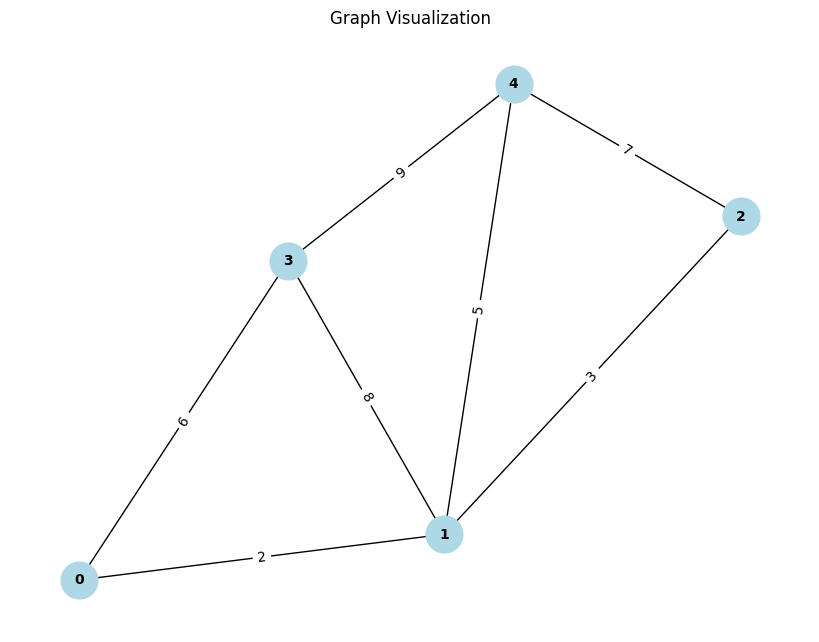

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a graph object (if not already created or if we want a fresh one for visualization)
# We'll use the 'g' object already defined in the previous cell.

# Create a NetworkX graph from the adjacency matrix
G = nx.Graph()

num_vertices = g.V

# Add nodes to the graph
G.add_nodes_from(range(num_vertices))

# Add edges to the graph from the adjacency matrix
for i in range(num_vertices):
    for j in range(i + 1, num_vertices): # Avoid duplicate edges and self-loops
        weight = g.graph[i][j]
        if weight > 0: # Only add edges with positive weight
            G.add_edge(i, j, weight=weight)

# Draw the graph
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G) # Layout for the nodes
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=700, font_size=10, font_weight='bold')
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels) # Corrected function name
plt.title("Graph Visualization")
plt.show()